# Drew's Test Code

## 1. Open data

In [2]:
import pandas as pd
import geopandas as gpd
import dask_geopandas as dgpd
import matplotlib.pyplot as plt
import shapely

In [2]:
USA_48_STATES_BBOX = (-128.320313,24.367114,-65.039063,50.401515)

In [3]:
us_chargers = pd.read_csv('data/USChargingLocations.csv')
us_chargers = gpd.GeoDataFrame(us_chargers, geometry = gpd.points_from_xy(us_chargers['Longitude'], us_chargers['Latitude']))
us_chargers = us_chargers.cx[USA_48_STATES_BBOX[0]:USA_48_STATES_BBOX[2], USA_48_STATES_BBOX[1]:USA_48_STATES_BBOX[3]]

/var/folders/rd/8mbxk5gd789c6ptzwnn0v70w0000gn/T/ipykernel_11639/937759518.py:1: DtypeWarning: Columns (20,40,64,69) have mixed types. Specify dtype option on import or set low_memory=False.
  us_chargers = pd.read_csv('data/USChargingLocations.csv')


In [16]:
interstates = gpd.read_file('data/spatial_interstates_w_mobility.geojson', bbox = USA_48_STATES_BBOX)
interstates.shape

(875213, 99)

In [18]:
interstates['sectionlength'].value_counts()

sectionlength
0.1      461374
0.01      17726
0.02      13100
0.03      10261
0.04       8742
          ...  
0.672         1
2.545         1
3.852         1
2.324         1
2.07          1
Name: count, Length: 5678, dtype: int64

In [63]:
interstates_simple = interstates[[':id', 'aadt', 'sectionlength', 'geometry']]

In [64]:
interstates_simple.loc[:, 'sectionlength'] = interstates_simple['sectionlength'].astype('float')
interstates_simple.loc[:, 'aadt'] = interstates_simple['aadt'].astype('float')

In [65]:
interstates_simple = interstates_simple.to_crs('EPSG:9311')
interstates_simple['geometry'] = interstates_simple.simplify(500)
interstates_simple = interstates_simple[interstates_simple.is_valid & ~interstates_simple.is_empty]

In [62]:
# ax = interstates.plot(color='grey')
# us_chargers.plot(ax = ax, color='red', markersize=0.5)
# ax.set_axis_off()

In [80]:
us_chargers = us_chargers.set_crs('EPSG:4326')
us_chargers.crs == interstates.crs

True

## Fill AADT with value of nearest non-null segment

In [66]:
has_aadt = interstates_simple[~interstates_simple['aadt'].isna()].copy()
no_aadt = interstates_simple[interstates_simple['aadt'].isna()].copy()

resolved_aadt = gpd.sjoin_nearest(
    no_aadt.drop(columns='aadt'),
    has_aadt[['aadt', 'geometry']],
    how = 'left'
)

resolved_aadt

interstates_simple.loc[resolved_aadt.index, 'aadt'] = resolved_aadt['aadt']

## Calculate VMT

In [67]:
interstates_simple['vmt'] = interstates_simple['aadt'] * interstates_simple['sectionlength']

In [68]:
interstates_simple

,:id,aadt,sectionlength,geometry,vmt
0,row-v8dg-ewdu-k3ak,27419.0,0.1,"LINESTRING (-1266073.493 -1161535.82, -1265997...",2741.9
1,row-26py.92cf.2ike,27419.0,0.1,"LINESTRING (-1266149.529 -1161509.205, -126607...",2741.9
2,row-fnsn.2thz~uvuj,27419.0,0.1,"LINESTRING (-1266225.565 -1161482.59, -1266149...",2741.9
3,row-p23a.ttjk_mxpq,27419.0,0.1,"LINESTRING (-1266301.6 -1161455.974, -1266225....",2741.9
4,row-iy36~3qmu_adbe,27419.0,0.1,"LINESTRING (-1266377.635 -1161429.357, -126630...",2741.9
...,...,...,...,...,...
875208,row-pxdx_6s78~26ik,3793.0,0.1,"LINESTRING (-505713.456 -67440.138, -505560.96...",379.3
875209,row-jbv6_gdth~fe3a,3793.0,0.1,"LINESTRING (-505860.48 -67376.053, -505713.456...",379.3
875210,row-s5up_fvss-dayc,3793.0,0.1,"LINESTRING (-506001.121 -67298.775, -505860.48...",379.3
875211,row-ytxt_kb5z_mmr8,3793.0,0.1,"LINESTRING (-506134.495 -67209.432, -506001.12...",379.3


In [70]:
# interstates_simple[0:10000].explore(cmap='inferno', column='vmt')

## 2. Filter US Chargers

In [71]:
interstates_1_mile = interstates.to_crs('EPSG:9311').buffer(1609.344)
# merged_interstates_buffer = interstates_1_mile.union_all()

/opt/anaconda3/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


In [81]:
chargers_by_interstate = gpd.sjoin(
    us_chargers.to_crs('EPSG:9311'), 
    gpd.GeoDataFrame(geometry=interstates_1_mile), 
    how="inner", 
    predicate="intersects"
).drop_duplicates(subset='ID')

In [20]:
interstates.iloc[0, :].to_clipboard()

In [47]:
# dask_chargers = dgpd.from_geopandas(us_chargers.to_crs('EPSG:9311'), npartitions=4)
# result = dask_chargers[dask_chargers.within(merged_interstates_buffer)]
# chargers_near_interstate = result.compute()

In [ ]:
# chargers_near_interstate = us_chargers.to_crs('EPSG:9311').within(merged_interstates_buffer)

In [63]:
print(interstates_simple.total_bounds)

[-1952079.01431408 -2111246.854987    2399583.82264467   681288.33806999]


Interstate Bounds: [-1952079.01431408 -2111246.854987    2399583.82264467   681288.33806999]
Buffer Bounds: [-1991114.77669242 -2123178.28299194  2435499.134888     719872.73064663]


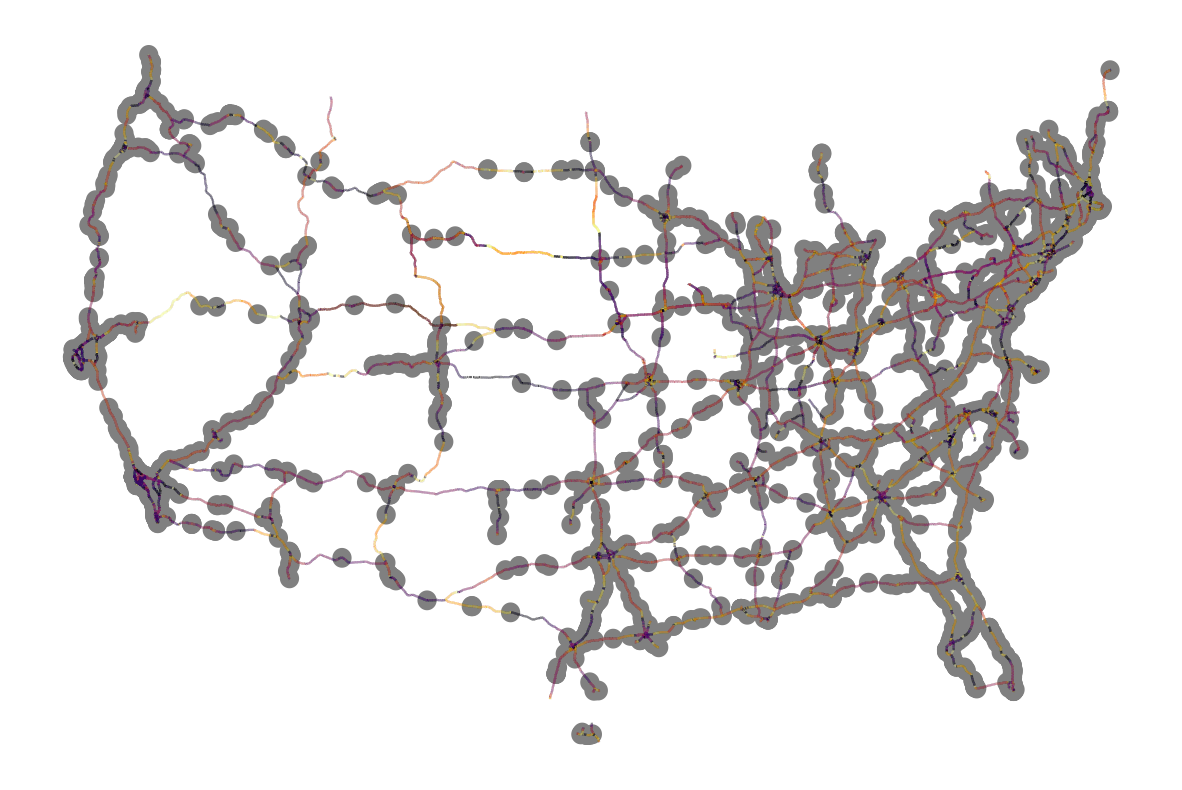

In [35]:
fig, ax = plt.subplots(figsize=(15, 10))

charger_buffers = chargers_by_interstate.to_crs('EPSG:9311')
charger_buffers = charger_buffers.buffer(1609.344 * 25)

charger_buffers = charger_buffers[charger_buffers.is_valid & ~charger_buffers.is_empty]

interstates_simple.plot(ax = ax, alpha = 0.5, column='aadt', cmap='inferno', legend=False)
charger_buffers.plot(ax = ax, color='gray', markersize=0.5)

ax.set_aspect('auto')
ax.set_axis_off()

In [8]:
# interstates.cx[-89.356441:-89.213791,43.067759:43.152601].plot(column='aadt', cmap='inferno')
# interstates.cx[-89.303055:-89.265289,43.088824:43.116648]

<Axes: >

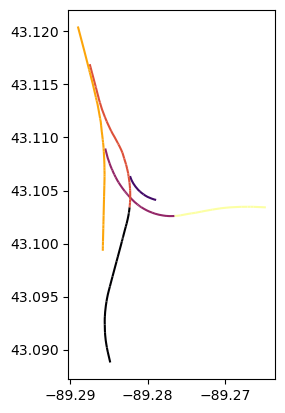

In [23]:
interstates.cx[-89.303055:-89.265289,43.088824:43.116648].dissolve(by='route_id', aggfunc={
    'aadt': 'max',      # Picks the best AADT value available for that route
    # 'county': 'first',  # Keeps other attributes
    # 'speed_limit': 'median' 
}).plot(column='aadt', cmap='inferno')

In [34]:
test = interstates.cx[-89.303055:-89.265289,43.088824:43.116648].geometry.apply(shapely.force_2d).apply(lambda g: shapely.set_precision(g, 1.0))

test[test.is_valid]

834977    LINESTRING Z EMPTY
834978    LINESTRING Z EMPTY
834979    LINESTRING Z EMPTY
834980    LINESTRING Z EMPTY
834981    LINESTRING Z EMPTY
                 ...        
851961    LINESTRING Z EMPTY
851962    LINESTRING Z EMPTY
851963    LINESTRING Z EMPTY
851964    LINESTRING Z EMPTY
851965    LINESTRING Z EMPTY
Name: geometry, Length: 143, dtype: geometry

## How many chargers by a segment?

In [73]:
us_charger_units = pd.read_csv('data/USAllChargingUnits.csv')
us_charger_units = gpd.GeoDataFrame(us_charger_units, geometry = gpd.points_from_xy(us_charger_units['Longitude'], us_charger_units['Latitude']))
us_charger_units = us_charger_units.cx[USA_48_STATES_BBOX[0]:USA_48_STATES_BBOX[2], USA_48_STATES_BBOX[1]:USA_48_STATES_BBOX[3]]
us_charger_units = us_charger_units.set_crs('EPSG:4326')

/var/folders/rd/8mbxk5gd789c6ptzwnn0v70w0000gn/T/ipykernel_11639/3204931791.py:1: DtypeWarning: Columns (3,20,31,40,46,63,64,69,74) have mixed types. Specify dtype option on import or set low_memory=False.
  us_charger_units = pd.read_csv('data/USAllChargingUnits.csv')


In [76]:
charging_units_by_interstate = gpd.sjoin(
    us_charger_units.to_crs('EPSG:9311'), 
    gpd.GeoDataFrame(geometry=interstates_1_mile).to_crs('EPSG:9311'), 
    how="inner", 
    predicate="intersects"
).drop_duplicates(subset = 'index_right')

/opt/anaconda3/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


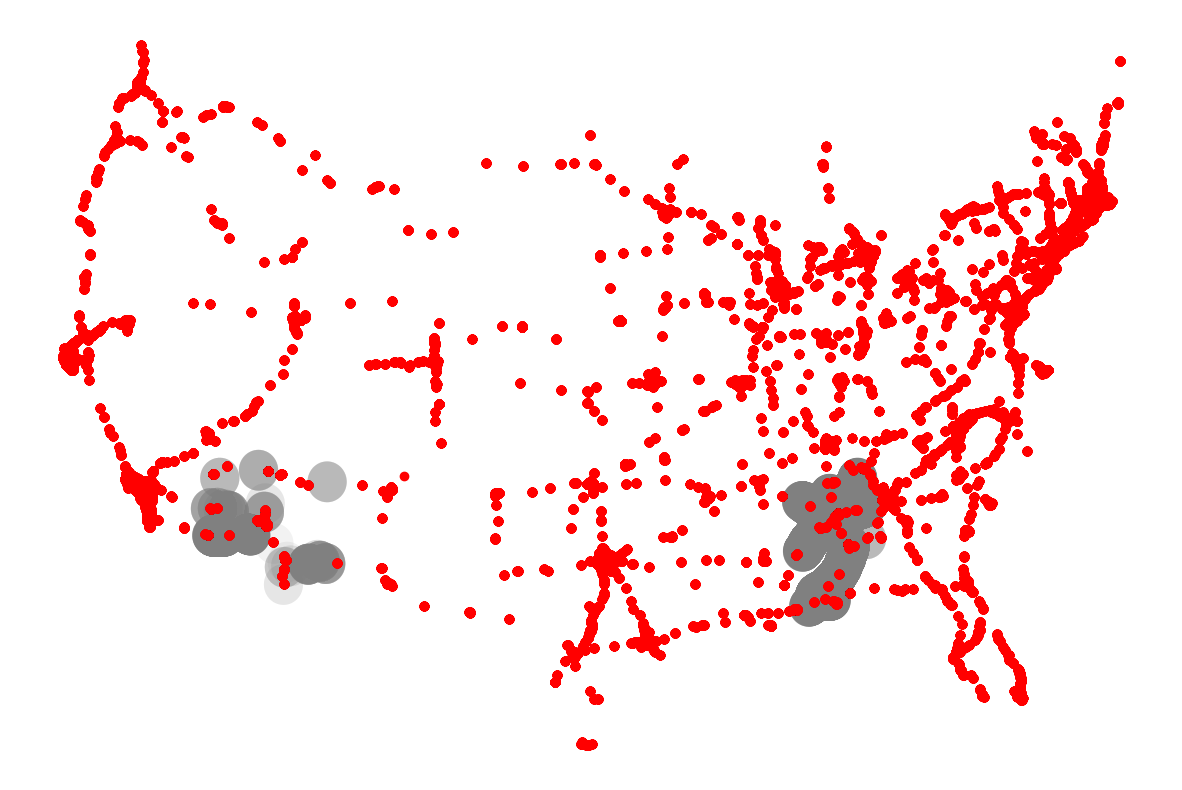

In [61]:
fig, ax = plt.subplots(figsize=(15, 10))

interstates_simple.iloc[0:10000].buffer(80467.2).plot(ax = ax, color = "gray", alpha = 0.1)
charging_units_by_interstate.plot(ax = ax, color = "red")

ax.set_aspect('auto')
ax.set_axis_off()

In [15]:
interstates_buffer_50mi = interstates_simple.copy()
interstates_buffer_50mi['geometry'] = interstates_buffer_50mi.buffer(80467.2)

/opt/anaconda3/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


In [ ]:
# joined_data = gpd.sjoin(
#     charging_units_by_interstate, 
#     interstates_buffer_50mi, 
#     how="inner", 
#     predicate="intersects"
# )

In [77]:
charging_units_by_interstate

,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,...,EV CCS Connector Count,EV CCS Power Output (kW),EV CHAdeMO Connector Count,EV CHAdeMO Power Output (kW),EV J3400 Connector Count,EV J3400 Power Output (kW),EV J3271 Connector Count,EV J3271 Power Output (kW),geometry,index_right
0,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,...,0,NaN,0,NaN,0,NaN,0,NaN,POINT (-1675199.618 -1035470.285),95629
0,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,...,0,NaN,0,NaN,0,NaN,0,NaN,POINT (-1675199.618 -1035470.285),95628
0,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,...,0,NaN,0,NaN,0,NaN,0,NaN,POINT (-1675199.618 -1035470.285),95627
0,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,...,0,NaN,0,NaN,0,NaN,0,NaN,POINT (-1675199.618 -1035470.285),95626
0,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,...,0,NaN,0,NaN,0,NaN,0,NaN,POINT (-1675199.618 -1035470.285),95625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66966,ELEC,The Last Drop - Tesla Supercharger (Francis En...,5425 N Lincoln Blvd,NaN,Oklahoma City,OK,73105,NaN,877-798-3752,E,...,1,325.0,0,NaN,1,325.0,0,NaN,POINT (226661.236 -1048959.035),604360
66966,ELEC,The Last Drop - Tesla Supercharger (Francis En...,5425 N Lincoln Blvd,NaN,Oklahoma City,OK,73105,NaN,877-798-3752,E,...,1,325.0,0,NaN,1,325.0,0,NaN,POINT (226661.236 -1048959.035),604391
66966,ELEC,The Last Drop - Tesla Supercharger (Francis En...,5425 N Lincoln Blvd,NaN,Oklahoma City,OK,73105,NaN,877-798-3752,E,...,1,325.0,0,NaN,1,325.0,0,NaN,POINT (226661.236 -1048959.035),604390
66966,ELEC,The Last Drop - Tesla Supercharger (Francis En...,5425 N Lincoln Blvd,NaN,Oklahoma City,OK,73105,NaN,877-798-3752,E,...,1,325.0,0,NaN,1,325.0,0,NaN,POINT (226661.236 -1048959.035),604160


In [82]:
charging_units_by_interstate_clean = charging_units_by_interstate[['geometry']]
chargers_by_interstate_clean = chargers_by_interstate[['geometry']]

In [83]:
def find_near_chargers(partition, points):
    return gpd.sjoin_nearest(partition, points, how="inner", max_distance = 80467.2)

In [84]:
d_interstates = dgpd.from_geopandas(interstates_simple, npartitions=24)

joined = d_interstates.map_partitions(find_near_chargers, charging_units_by_interstate_clean)
d_results = joined.compute(scheduler='threads')

In [ ]:
def find_dist_to_nearest_charger(partition, points):
    if partition.empty:
        return partition
    
    return gpd.sjoin_nearest(
        partition, 
        points, 
        how="left", 
        distance_col="dist_to_charger"
    )

joined_delayed = d_interstates.map_partitions(
    find_dist_to_nearest_charger, 
    points=chargers_by_interstate_clean
)

interstates_with_info = joined_delayed.compute(scheduler='threads')

In [87]:
interstates_with_info['dist_charger_miles'] = interstates_with_info['dist_to_charger'] / 1609.344

In [75]:
interstates_simple.shape

(875213, 100)

In [86]:
charger_counts = d_results.groupby(d_results.index).size()
interstates_with_info['charger_count_within_50_miles'] = charger_counts
interstates_with_info['charger_count_within_50_miles'] = interstates_with_info['charger_count_within_50_miles'].fillna(0)
interstates_with_info['charger_count_within_50_miles'].value_counts()

charger_count_within_50_miles
0.0      43276
27.0     24865
31.0     23773
29.0     22371
32.0     22281
         ...  
335.0       69
141.0       52
104.0       47
322.0       24
174.0        7
Name: count, Length: 155, dtype: int64

In [81]:
interstates_with_info.iloc[0].to_clipboard()

In [82]:
interstates_with_info = interstates_with_info.sort_values('dist_to_charger').drop_duplicates(subset=[':id'])

,aadt,aadt_combination,aadt_d,aadt_single_unit,access_control,at_grade_other,base_thickness,base_type,begin_point,counter_peak_lanes,...,year_last_improvement,year_record,:id,:version,:created_at,:updated_at,geometry,charger_count,index_charger,dist_to_charger
128736,<NA>,<NA>,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,<NA>,...,NaT,2024,row-6ct4_ruxr.kyaz,rv-4t9m.58qt_34dv,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (2212832.661 -40935.902, 2212551.31...",NaN,7149,0.127097
129971,110700,4058,2023-01-01,1925,1,0,9,2,93.8,3,...,2015-01-01,2024,row-jy2s~mn2n.fxmm,rv-yy7p-y4s4~5u4j,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (2274167.251 -11208.706, 2274314.45...",NaN,7717,0.416276
575530,<NA>,<NA>,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,1.4,<NA>,...,NaT,2024,row-ydxd~nbcc_px7w,rv-we5v_kwcw_djdq,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (1329301.671 -531184.656, 1329325.9...",NaN,9517,0.523555
129706,<NA>,<NA>,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,<NA>,...,NaT,2024,row-ixq8_srxx_yedm,rv-z5ph.b2qz~ftet,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (2165132.744 -93368.574, 2166303.39...",NaN,2986,1.645417
557749,<NA>,<NA>,NaT,<NA>,<NA>,<NA>,<NA>,<NA>,4.044,<NA>,...,NaT,2024,row-3ade-x9ip~vxjr,rv-akjd.cg4j-mjvb,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (1571010.655 -893800.884, 1570311.2...",NaN,3243,1.812551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678113,7318,1793,2024-12-31,176,1,0,15,3,199.595,2,...,2009-01-01,2024,row-mxsb.gxxz~zf23,rv-5g8g_ansn.pspu,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (-46767.6 -121192.732, -46607.341 -...",NaN,5222,307767.010034
680448,7318,1793,2024-12-31,176,1,<NA>,18,3,199.754,<NA>,...,2009-01-01,2024,row-ce27.tv78-cg7p,rv-xuve~agva~pc4y,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (-46440.13 -121162.992, -46279.692 ...",NaN,7932,307802.466869
678110,7318,1793,2024-12-31,176,1,0,15,3,199.795,2,...,2009-01-01,2024,row-x8bg.t6yz-4w8h,rv-xk43.sjvr~3a6v,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (-46447.078 -121193.903, -46286.862...",NaN,7932,307806.723786
678112,7318,1793,2024-12-31,176,1,0,15,3,199.695,2,...,2009-01-01,2024,row-ft7p_fhhe-vbeb,rv-2bi9_mdph~nmrb,2025-11-12 14:39:46.234000+00:00,2025-11-12 14:39:46.234000+00:00,"LINESTRING (-46607.341 -121193.349, -46447.078...",NaN,5222,307923.840707


In [50]:
interstates_simple.sort_values('charger_count', ascending=False)[['charger_count']]

,charger_count
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
875208,NaN
875209,NaN
875210,NaN
875211,NaN


## Fill AADT

In [ ]:
interstates_with_info

,:id,aadt,sectionlength,geometry,vmt,index_charger,dist_to_charger,charger_count_within_50_miles,dist_charger_miles
0,row-v8dg-ewdu-k3ak,27419.0,0.1,"LINESTRING (-1266073.493 -1161535.82, -1265997...",2741.9,5955,52407.000273,52.0,32.564200
1,row-26py.92cf.2ike,27419.0,0.1,"LINESTRING (-1266149.529 -1161509.205, -126607...",2741.9,5955,52326.680338,52.0,32.514292
2,row-fnsn.2thz~uvuj,27419.0,0.1,"LINESTRING (-1266225.565 -1161482.59, -1266149...",2741.9,5955,52246.361342,52.0,32.464384
3,row-p23a.ttjk_mxpq,27419.0,0.1,"LINESTRING (-1266301.6 -1161455.974, -1266225....",2741.9,5955,52166.043288,52.0,32.414477
4,row-iy36~3qmu_adbe,27419.0,0.1,"LINESTRING (-1266377.635 -1161429.357, -126630...",2741.9,5955,52085.726180,52.0,32.364570
...,...,...,...,...,...,...,...,...,...
875208,row-pxdx_6s78~26ik,3793.0,0.1,"LINESTRING (-505713.456 -67440.138, -505560.96...",379.3,11341,30480.582523,89.0,18.939756
875209,row-jbv6_gdth~fe3a,3793.0,0.1,"LINESTRING (-505860.48 -67376.053, -505713.456...",379.3,11341,30323.443510,89.0,18.842114
875210,row-s5up_fvss-dayc,3793.0,0.1,"LINESTRING (-506001.121 -67298.775, -505860.48...",379.3,11341,30163.956718,89.0,18.743014
875211,row-ytxt_kb5z_mmr8,3793.0,0.1,"LINESTRING (-506134.495 -67209.432, -506001.12...",379.3,11341,30003.469011,89.0,18.643291


In [92]:
interstates_with_info.to_file('data/interstates_with_charger_info.geojson', driver='GeoJSON')

## Aggregate by zipcode

In [9]:
zcta = gpd.read_file('data/zcta_shapefile/tl_2025_us_zcta520.shp')
interstates_with_info = gpd.read_file('data/interstates_with_charger_info.geojson')

In [21]:
zcta = zcta[['ZCTA5CE20', 'geometry']]
zcta = zcta.rename({"ZCTA5CE20": "zip_code"}, axis = 1)

In [12]:
zcta = zcta.to_crs('EPSG:9311')
interstates_with_info = interstates_with_info.to_crs('EPSG:9311')

In [14]:
interstates_with_info['centroid'] = interstates_with_info.geometry.centroid

In [23]:
interstates_with_info = gpd.sjoin(
    interstates_with_info.set_geometry('centroid'),
    zcta,
    how = "left",
    predicate = "within"
)

In [28]:
interstates_with_info.groupby('zip_code')['dist_charger_miles'].mean().sort_values(ascending=False)

zip_code
57531    186.164535
57559    185.141171
57576    177.757961
57562    173.536321
57568    167.705122
            ...    
07961      0.033817
80205      0.026949
33461      0.012687
34212      0.011054
60189      0.010783
Name: dist_charger_miles, Length: 8283, dtype: float64